# DAU 차트를 봐서는 DAU를 올릴 수 없다 — 유저 세그먼트 분석 실습

DAU 한 줄짜리 그래프로는 신규 유저의 안착도, 헤비 유저의 이탈 징후도, 잠들었던 유저의 부활도
모두 한 점으로 뭉개져 보이지 않습니다. 이 노트북은 가상의 습관 트래커 앱 ‘루틴로그’의 유저를 **5개 세그먼트**로 쪼개고,
세그먼트 사이의 **이동(Flow)** 과 비율 지표로 서비스 건강도를 입체적으로 들여다봅니다.
그림과 표가 꽤나 복잡해 보이지만, 막상 SQL로 옮겨 보면 의외로 단순한 데이터 구조 위에서
돌아간다는 사실을 확인할 수 있습니다.

분석은 두 개의 원천 테이블에서 출발합니다.

| 테이블 | 입자 단위 | 역할 |
| :-- | :-- | :-- |
| `user_master` | user_id (유저당 1행) | 유저별 가입(첫 기록) 정보 — 언제 처음 우리 서비스를 만났는가 |
| `user_activity` | user_id × event_date | 유저가 습관 체크를 남긴 날의 기록 — 어느 날 서비스를 실제로 썼는가 |

- **실습 1.** 두 테이블에서 3개 파생지표(`days_since_signup`, `active_day_count`, `last_active_date`)를 만들고, 정해진 기준에 따라 5개 세그먼트(new / heavy / light / risk / dormant)로 분류합니다. 세그먼트에 ‘오늘 기록 여부’를 교차해 DAU 구성도 확인합니다.
- **실습 2.** 어제·오늘 두 시점의 세그먼트를 한 행에 담아, 세그먼트 변화를 추적할 수 있는 마트를 만듭니다.
- **실습 3.** 그 마트를 분포(Stock) · 전이 행렬(Flow) · 비율 지표(HURR/CURR/Heavy Loss/Light Loss/Reactivation) 세 각도로 분석합니다.
- **실습 4.** 마트를 여러 날 적재해, 30일 전 heavy 유저와 new 유저가 오늘 어디로 흩어졌는지 N일 변화를 추적합니다.

쿼리는 모두 **DuckDB**로 예시 CSV에 직접 실행합니다.

## 0. 실습용 데이터 준비

아래 셀은 의존성 설치와 실습 환경(연결·상수·테이블 등록)을 한 번에 구성합니다.
데이터가 없다면 먼저 터미널에서 `python generate_data.py` 를 실행해 예시 데이터를
만들어 주세요 (`data/user_master.csv`, `data/user_activity.csv`).

> **[내 데이터 적용]** 분석 기준일(`TARGET`)을 내 날짜로 바꿉니다. 단, 쿼리들에는
> `'2026-05-20'` 이 문자열로 박혀 있어 기준일을 바꾸려면 각 쿼리의 날짜도 함께 바꿔야
> 합니다(실습 4처럼 `.replace` 로 일괄 치환해도 됩니다).

### 두 테이블: user_master 와 user_activity

실습에는 유저별 가입 정보가 기록된 `user_master` 와, 유저의 행동 로그가 기록된
`user_activity` 두 테이블이 필요합니다. 굳이 두 테이블로 분리해 두는 이유는, 담고 있는
데이터의 성격이 다르기 때문입니다. 첫 기록일은 유저당 한 번만 기록되는 정적 마스터
테이블이고, 일별 기록은 매일 새로 쌓이는 로그 테이블입니다. 루틴로그에서 ‘활동’은 접속이
아니라 그날 습관 체크를 남긴 것이므로, `user_activity` 의 한 행은 ‘어느 유저가 어느 날
기록을 남겼다’를 뜻합니다. 갱신 주기도, 사용되는 맥락도
다른 두 데이터를 한 테이블에 한꺼번에 담지 않는 편이 마트 운영과 분석 모두에 더 유리합니다.

두 CSV는 아래 셀에서 DuckDB 테이블로 등록해 두고, 이후 모든 쿼리에서 테이블 이름으로
참조합니다. 분석 기준일은 TARGET 상수로 들어 있지만, 아래 SQL에는 이 날짜가 문자열로
직접 박혀 있어서 기준일을 바꾸려면 각 쿼리의 날짜도 함께 바꿔야 합니다. DuckDB는 별도 서버 설치 없이 파이썬 안에서 바로 SQL을 돌릴 수 있는 가벼운
분석용 DB인데요. 여기서 쓰는 SQL은 거의 표준 문법이라, 사내 웨어하우스(BigQuery,
Redshift 등)로 옮길 때도 함수 몇 개만 손보면 됩니다.

> **[내 데이터 적용]** 내 서비스의 두 테이블로 바꿉니다 —
> `user_master(user_id, first_active_date)`, `user_activity(user_id, event_date)`.

In [1]:
# 의존성 설치 및 실습 환경 구성
%pip install -q -r requirements.txt

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()   # 인메모리 연결 하나를 노트북 전체에서 재사용
SEG_ORDER = ["new", "heavy", "light", "risk", "dormant"]
TARGET = "2026-05-20"    # 분석 기준일

# CSV 두 개를 테이블로 한 번만 등록 — 이후 쿼리는 테이블 이름으로 참조
for t in ["user_master", "user_activity"]:
    q = f"CREATE TABLE {t} AS SELECT * FROM read_csv_auto('data/{t}.csv')"
    con.execute(q)
con.execute("SELECT * FROM user_activity").df().head()


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


,user_id,event_date
0,user_032,2026-01-27
1,user_144,2026-01-27
2,user_144,2026-01-28
3,user_123,2026-01-29
4,user_144,2026-01-29


## 실습 1. 3개의 파생지표로 5개 세그먼트 분류하기

`user_master` 혹은 `user_activity` 테이블만 살펴봐서는 개별 유저가 어떤 세그먼트에
속하는지 파악하기 어렵습니다. 이 두 테이블은 어디까지나 분석을 위한 기초 데이터일 뿐이고,
세그먼트 구분을 위해서는 한 단계의 가공이 더 필요합니다.

5개 세그먼트(new, heavy, light, risk, dormant)는 결국 다음 3개의 축으로 결정됩니다.

| 축 | 의미 |
| :-- | :-- |
| `days_since_signup` | 가입(첫 기록) 후 며칠째인가? |
| `active_day_count` | 최근 7일 중 며칠 기록했는가? |
| `last_active_date` | 가장 최근 기록일은? |

세그먼트 정의에는 들어가지 않지만 ‘오늘 기록했는가’(`d0_active`)도 같이 만들어 둡니다.
뒤에서 세그먼트별 DAU 구성을 볼 때 씁니다.


### 1.1. 파생지표 계산

`user_master` 와 `user_activity` 를 `LEFT JOIN` 한 뒤 유저 단위로 집계하면 파생지표를
한번에 만들 수 있습니다. 결과는 `user_metrics` 테이블에 담아 두고, 다음 단계의 분류 쿼리가
이 테이블을 입력으로 씁니다.

쿼리에 나오는 `bool_or`, `count_if` 는 '조건을 만족하는 행이 하나라도 있는가',
'조건을 만족하는 행이 몇 개인가'를 세는 DuckDB 집계 함수입니다. 만약 사내 데이터
웨어하우스가 이 함수를 지원하지 않는다면 각각 `MAX(CASE WHEN … THEN 1 ELSE 0 END)`,
`SUM(CASE WHEN … THEN 1 ELSE 0 END)` 로 바꿔 쓰면 됩니다.

In [2]:
# 파생지표 — user_master 와 user_activity 를 LEFT JOIN 해 유저 단위로 집계
con.execute("""
CREATE OR REPLACE TABLE user_metrics AS
SELECT
  m.user_id,
  -- 1. 가입(첫 기록) 후 며칠째인가 (가입 당일 = 0)
  datediff('day', m.first_active_date, DATE '2026-05-20') AS days_since_signup,
  -- 2. 최근 7일(기준일 포함) 기록 일수
  count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 6 DAY
                            AND DATE '2026-05-20') AS active_day_count,
  -- 3. 마지막 기록일 (가입 당일 기록이 보장되므로 항상 존재)
  max(CASE WHEN a.event_date <= DATE '2026-05-20'
      THEN a.event_date END) AS last_active_date,
  -- (+) 오늘 기록 여부
  bool_or(a.event_date = DATE '2026-05-20') AS d0_active
FROM user_master m LEFT JOIN user_activity a USING (user_id)
GROUP BY m.user_id, m.first_active_date
""")
con.execute("SELECT * FROM user_metrics ORDER BY user_id").df().head()

,user_id,days_since_signup,active_day_count,last_active_date,d0_active
0,user_001,0,1.0,2026-05-20,True
1,user_002,0,1.0,2026-05-20,True
2,user_003,0,1.0,2026-05-20,True
3,user_004,0,1.0,2026-05-20,True
4,user_005,0,1.0,2026-05-20,True


### 1.2. Segment 매핑

이제 위에서 만든 `user_metrics` 의 3개 지표를 **정해진 기준**에 따라 `CASE WHEN` 한 단계로
5개 세그먼트로 분류합니다. 분류 기준은 다음과 같습니다.

| 세그먼트 | 분류 기준 |
| :-- | :-- |
| `new` | 가입 후 7일 이내 (`days_since_signup < 7`) |
| `heavy` | 가입 8일차 이상 & 최근 7일 중 5일 이상 기록 |
| `light` | 가입 8일차 이상 & 최근 7일 중 1~4일 기록 |
| `risk` | 최근 7일 기록 0일 & 마지막 기록 7~30일 전 |
| `dormant` | 최근 7일 기록 0일 & 마지막 기록 30일 초과 |

> new 를 하루가 아니라 7일로 잡은 이유 — 가입 첫 주는 서비스를 익히는 기간이라 하루하루의
> 기록 여부보다 ‘첫 주를 지나서도 남아 있는가’가 중요합니다. 7일이 지나면 지난 일주일의
> 기록 일수에 따라 heavy/light 로, 기록이 없었다면 risk 로 자연스럽게 넘어갑니다.
>
> risk·dormant 분기는 마지막 기록일만으로 가릅니다 — `active_day_count = 0` 이면
> 최근 7일 기록이 없다는 뜻이라, ‘마지막 기록이 7일 이전인지’를 따로 검사할 필요가 없기
> 때문입니다.


In [3]:
# 정해진 기준에 따라 5개 세그먼트로 분류 — 위에서 만든 user_metrics 를 입력으로 사용
seg = con.execute("""
SELECT
  *,
  CASE
    WHEN days_since_signup < 7           THEN 'new'
    WHEN active_day_count >= 5           THEN 'heavy'
    WHEN active_day_count BETWEEN 1 AND 4 THEN 'light'
    -- active_day_count = 0 이면 최근 7일 기록이 없다는 뜻이므로,
    -- risk/dormant 는 마지막 기록일이 30일 안쪽인지로만 가르면 된다.
    WHEN last_active_date >= DATE '2026-05-20' - INTERVAL 30 DAY THEN 'risk'
    ELSE 'dormant'
  END AS user_seg
FROM user_metrics
ORDER BY user_id;
""").df()
print(seg["user_seg"].value_counts().reindex(SEG_ORDER))


user_seg
new        16
heavy      39
light      72
risk       53
dormant    20
Name: count, dtype: int64


5개 세그먼트가 모두 등장하도록 각 세그먼트에서 한 명씩 뽑아 보면, 3개 지표가
어떻게 하나의 세그먼트로 압축되는지 한눈에 들어옵니다.

In [4]:
# 각 세그먼트의 대표 유저를 한 명씩 발췌
sample = seg.groupby("user_seg").first().reindex(SEG_ORDER).reset_index()
sample[["user_seg", "user_id", "days_since_signup",
        "active_day_count", "last_active_date"]]

,user_seg,user_id,days_since_signup,active_day_count,last_active_date
0,new,user_001,0,1.0,2026-05-20
1,heavy,user_017,44,6.0,2026-05-20
2,light,user_018,54,1.0,2026-05-19
3,risk,user_021,87,0.0,2026-04-22
4,dormant,user_026,65,0.0,2026-04-16


세그먼트 정의 어디에도 ‘오늘 기록했는가’가 들어 있지 않은데, 그럼 DAU는 어디로 갔을까요?
세그먼트에 오늘의 기록 여부(`d0_active`)를 교차해 보면 됩니다. 오른쪽 열의 합이 오늘의 DAU 입니다.
같은 DAU 라도 heavy 가 채운 날과 new 가 채운 날은 전혀 다른 하루라는 것을, 이 표 하나로 볼 수 있습니다.


In [5]:
# 세그먼트별 오늘 기록 유저 수 — Stock 위에 DAU 를 얹어 본다
dau_by_seg = (seg.groupby("user_seg")
              .agg(users=("user_id", "count"),
                   active_today=("d0_active", "sum"))
              .reindex(SEG_ORDER))
dau_by_seg.loc["total"] = dau_by_seg.sum()
dau_by_seg.astype(int)

,users,active_today
user_seg,,
new,16,11
heavy,39,30
light,72,29
risk,53,0
dormant,20,0
total,200,70


## 실습 2. 세그먼트 변화 추적 가능한 데이터 마트 만들기

실습 1의 결과는 어느 한 시점의 스냅샷, 즉 **Stock** 에 해당합니다. 이 테이블이 있으면 기준
시점에 유저들이 각 세그먼트에 어떻게 분포돼 있는지를 확인할 수 있습니다. 하지만 아래와 같은
질문에 답하려면, **어제와 오늘 두 시점의 세그먼트를 한 행에 나란히 담아둔 데이터 마트**가
필요합니다.

1. 어제 heavy였던 유저 중 몇 명이 오늘 light로 떨어졌는가? (Heavy Loss)
2. 어제 risk였던 유저 중 누가 오늘 다시 활동으로 돌아왔는가? (Reactivation)
3. 어제 heavy였던 유저는 오늘도 heavy로 잘 남아 있는가? (HURR)
4. 가입 8일째를 맞은 new 유저는 heavy/light 로 안착했는가, risk 로 빠졌는가? (New Activation / New Loss)

먼저 실습 1의 분류 CASE를 기준일을 인자로 받는 **매크로**로 정의합니다. 오늘과 어제,
두 시점의 분류가 필요한데 같은 기준을 두 번 복사하는 대신 한 번 정의해 재사용하려는
것입니다.

MACRO는 DuckDB 문법이라 사내 웨어하우스에 없을 수 있는데요. BigQuery에서는 비슷한 목적으로
UDF를 사용할 수 있고, 아니면 CASE를 반복해서 사용해도 결과는 같습니다.

> **[내 데이터 적용]** 임계값(new 윈도·heavy 컷·경계일)을 내 서비스에 맞게 바꿀 때는 실습 1의
> 분류 CASE와 이 매크로 **두 곳을 똑같이** 고칩니다. 다만 '최근 7일'이라는 활동 윈도우는 CASE가
> 아니라 `count_if` 의 `INTERVAL 6 DAY`(어제 쪽은 `7 DAY`)에 있는데요. 윈도우를 14일로 늘리려면
> 실습 1의 파생지표 쿼리와 아래 마트 쿼리의 이 부분도 함께 바꿔야 합니다.

In [6]:
# 실습 1의 분류 CASE를 매크로로 정의 — 오늘/어제 두 시점에 재사용합니다.
# 기준일보다 뒤에 가입한 유저(days < 0)는 그 시점에 존재하지 않았으므로 NULL.
con.execute("""
CREATE OR REPLACE MACRO classify_seg(days, cnt, last_active, ref_date) AS
  CASE
    WHEN days < 0                          THEN NULL
    WHEN days < 7                          THEN 'new'
    WHEN cnt >= 5                          THEN 'heavy'
    WHEN cnt BETWEEN 1 AND 4               THEN 'light'
    -- cnt = 0 이면 최근 7일 기록이 없으므로 risk/dormant 는 마지막 기록일로만 가른다.
    WHEN last_active >= ref_date - INTERVAL 30 DAY THEN 'risk'
    ELSE 'dormant'
  END
""")


아래 쿼리는 3개 지표를 오늘·어제 두 시점으로 계산해 `user_seg`(오늘)와
`user_seg_from`(어제)을 한 행에 담고, 그 결과를 `mart_user_segment` 테이블로 적재합니다.

In [7]:
build_mart_query = """
CREATE OR REPLACE TABLE mart_user_segment AS
WITH metrics AS (
  SELECT
    m.user_id,
    -- 오늘(기준일) 지표
    datediff('day', m.first_active_date, DATE '2026-05-20') AS days,
    count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 6 DAY
                              AND DATE '2026-05-20') AS cnt,
    max(CASE WHEN a.event_date <= DATE '2026-05-20'
        THEN a.event_date END) AS last_active,
    -- 어제 지표 (같은 정의에서 윈도우만 하루 미룸)
    datediff('day', m.first_active_date,
             DATE '2026-05-20' - INTERVAL 1 DAY) AS days_from,
    count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 7 DAY
                          AND DATE '2026-05-20' - INTERVAL 1 DAY) AS cnt_from,
    max(CASE WHEN a.event_date <= DATE '2026-05-20' - INTERVAL 1 DAY
        THEN a.event_date END) AS last_active_from
  FROM user_master m LEFT JOIN user_activity a USING (user_id)
  GROUP BY m.user_id, m.first_active_date
)
SELECT
  DATE '2026-05-20' AS target_date, user_id,
  classify_seg(days_from, cnt_from, last_active_from,
               DATE '2026-05-20' - INTERVAL 1 DAY) AS user_seg_from,
  classify_seg(days, cnt, last_active, DATE '2026-05-20') AS user_seg
FROM metrics ORDER BY user_id;
"""
con.execute(build_mart_query)

적재가 잘 됐는지, 어제→오늘 변화가 뚜렷한 유저 몇 명만 골라 확인해 보겠습니다.

In [8]:
watch = ["user_041", "user_176", "user_048", "user_061", "user_115"]
mart = con.execute("SELECT user_id, user_seg_from, user_seg "
                   "FROM mart_user_segment").df()
mart.query("user_id in @watch")

,user_id,user_seg_from,user_seg
40,user_041,new,heavy
47,user_048,heavy,light
60,user_061,light,risk
114,user_115,risk,light
175,user_176,new,light


41번과 176번 유저는 어제까지 가입 첫 주(new)를 보내던 유저인데, 오늘 8일째를 맞으면서 지난
일주일의 기록 일수에 따라 각각 heavy 와 light 로 안착했습니다. 48번 유저는 주 5일 이상
기록하던 헤비 유저였지만, 최근 기록이 뜸해지면서 light 로 내려왔네요. 61번 유저는 light
였는데 일주일 내내 기록이 없어 risk 로 빠졌고, 115번 유저는 반대로 한동안 뜸하다가 오늘
다시 기록을 남겨 risk 에서 light 로 돌아왔습니다. 48번·61번처럼 내려가는 유저에게는
다시 기록을 남기도록 유도하는 액션이 필요한 시점이네요.


## 실습 3. Stock과 Flow 분석하기

이렇게 만든 데이터 마트가 매일 적재되어 누적된다고 가정하면, 이 마트 하나로 한 시점의
**분포(Stock)** 와 시점 간 **이동(Flow)**, 그리고 그 이동을 요약한 **비율 지표(KPI)** 를
모두 분석할 수 있습니다.

### 3.1. Stock - 일별 세그먼트 분포 확인하기

가장 먼저 확인할 수 있는 건 **한 시점에 우리 서비스의 유저들이 어떤 분포로 존재하는가**
입니다. 단순한 `GROUP BY` 한 번이면 계산할 수 있습니다.

,users
user_seg,
new,16
heavy,39
light,72
risk,53
dormant,20


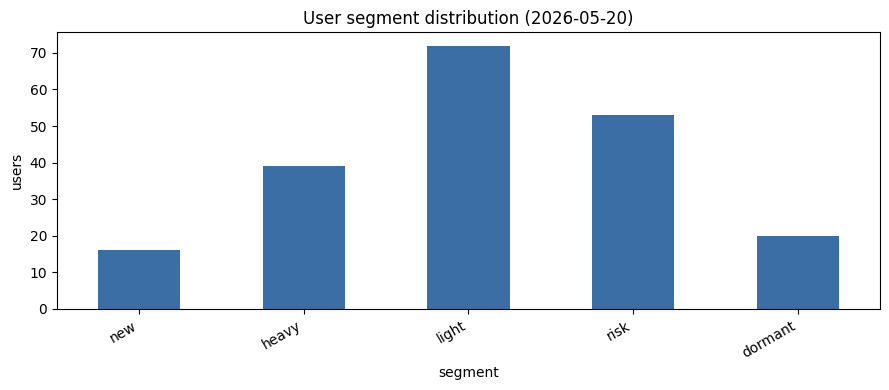

In [9]:
# 일별 세그먼트 분포 (Stock) — 정렬은 pandas reindex 가 담당
dist = con.execute("""
SELECT user_seg, count(*) AS users
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20'
GROUP BY user_seg
""").df().set_index("user_seg").reindex(SEG_ORDER)
display(dist)

ax = dist["users"].plot.bar(figsize=(9, 4), color="#3b6ea5")
ax.set_title("User segment distribution (2026-05-20)")
ax.set_xlabel("segment"); ax.set_ylabel("users")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

이 표는 *오늘* 우리 서비스의 유저들이 어디에 모여 있는지를 보여주는
횡단면(cross-section)입니다. 지금은 마트에 하루치 데이터만 들어 있지만, 실습 4까지 진행한
후 `target_date` 를 바꿔가며 같은 쿼리를 돌려 보면 세그먼트 구성이 어떻게 달라지는지
관찰할 수 있습니다. 가령 heavy의 절대 수가 줄고 있는데 light가 같이 늘고
있다면, 헤비 유저의 이탈이 서서히 진행되고 있다는 신호로 읽을 수 있겠죠.

### 3.2. Flow - 세그먼트 전이 행렬 확인하기

Stock 만 봐서는, heavy 의 수가 어제와 비슷하게 유지된다고 해도 그게 그대로 남은
유저인지 빠진 자리를 다른 유저가 채운 건지 구별할 수 없습니다. 그 차이를 보려면 세그먼트
전이 행렬을 만들어서 보는 게 간편합니다. 다행히 우리가 만든 데이터 마트에는 그 정보가
이미 들어 있습니다 — 어제(`user_seg_from`)를 행, 오늘(`user_seg`)을 열로 펼치면
전이 행렬이 됩니다.

In [10]:
# 세그먼트 전이 (Flow): 어제(user_seg_from) → 오늘(user_seg)
trans = con.execute("""
SELECT user_seg_from, user_seg, count(*) AS users
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20'
  AND user_seg_from IS NOT NULL   -- 오늘 처음 가입한 유저(어제 NULL)는 제외
GROUP BY user_seg_from, user_seg
""").df()

order = SEG_ORDER
pivot = (trans.pivot(index="user_seg_from", columns="user_seg", values="users")
              .reindex(index=order, columns=order))
pivot.fillna(0).astype(int)


user_seg,new,heavy,light,risk,dormant
user_seg_from,,,,,
new,6,1,1,0,0
heavy,0,35,3,0,0
light,0,3,67,4,0
risk,0,0,1,49,1
dormant,0,0,0,0,19


이 행렬을 히트맵으로 그리면 전이가 어디에 몰려 있는지 한눈에 들어옵니다.

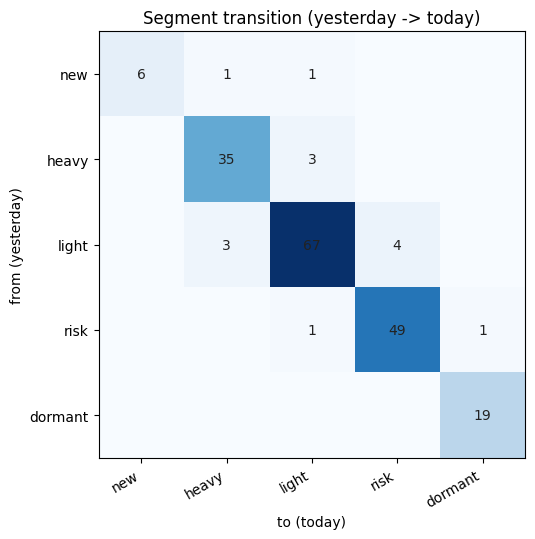

In [11]:
# 전이 행렬 히트맵
m = pivot.values.astype(float)
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.imshow(np.nan_to_num(m), cmap="Blues")
ax.set_xticks(range(len(order)), order, rotation=30, ha="right")
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("to (today)"); ax.set_ylabel("from (yesterday)")
for i in range(len(order)):
    for j in range(len(order)):
        if not np.isnan(m[i, j]):
            ax.text(j, i, int(m[i, j]), ha="center", va="center", color="#222")
ax.set_title("Segment transition (yesterday -> today)")
plt.tight_layout(); plt.show()

행과 열은 new 를 맨 앞에 두고, 그 뒤로 활동성이 높은 순(heavy)에서 낮은 순(dormant)으로 정렬되어
있는데요. new 행은 따로 읽습니다 — 어제 new 였던 8명 중 6명은 아직 첫 주 안에 있어 new 에 남았고,
8일째를 맞은 2명은 heavy 와 light 로 한 명씩 안착했습니다(New Activation). risk 로 빠진 유저(New Loss)는
이날 없었네요. 한편 오늘 막 가입한 10명은 어제 세그먼트가 없어서 이 행렬에서는 빠져 있는데요.
그래서 new 열의 합(6명)이 Stock의 new(16명)보다 작습니다. 나머지 네 행은 아래와 같이 세 가지
방향으로 읽어서 해석하면 됩니다.

1. **대각선**: 어제와 오늘의 세그먼트가 같은 유저들. 안정적으로 유지되고 있음을 의미.
2. **대각선 위쪽** (같은 행에서 오른쪽 셀): 활동성이 떨어진 유저들
   (예: heavy → light, light → risk). 이탈 징후로 모니터링해야 할 영역.
3. **대각선 아래쪽** (같은 행에서 왼쪽 셀): 활동성이 더 높아진 유저들
   (예: light → heavy, risk → light). 긍정적 전이로 볼 수 있는 영역.

### 3.3. 비율 지표 생성하기

전이 행렬에서 여러 가지 의미 있는 비율 지표들을 뽑아낼 수 있습니다. 몇 가지 예시를 들면
아래와 같습니다.

1. **HURR (Heavy → Heavy)**: Heavy 유저의 유지율
2. **CURR (Heavy + Light → Heavy + Light)**: Heavy+Light 유저의 유지율
3. **Heavy Loss (Heavy → Light)**: Heavy 에서 Light 유저로 전이된 비율
4. **Light Loss (Light → Risk)**: Light 에서 Risk 유저로 전이된 비율
5. **Reactivation (Risk → Light)**: Risk 에서 Light 유저로 전이된 비율

heavy·light 를 묶은 `core` 는 앞으로도 계속 쓰게 되므로, SQL에 끼워 넣을 문자열 상수로
정의해 둡니다.

In [12]:
core = "('heavy', 'light')"   # 핵심 활동 유저 = heavy + light

# 분모가 0이 되는 경우를 막기 위해 nullif(..., 0) 으로 감싼다.
kpi = con.execute(f"""
SELECT
  round(count_if(user_seg_from = 'heavy' AND user_seg = 'heavy')
    / nullif(count_if(user_seg_from = 'heavy'), 0) * 100, 1) AS hurr_pct,
  round(count_if(user_seg_from IN {core} AND user_seg IN {core})
    / nullif(count_if(user_seg_from IN {core}), 0) * 100, 1) AS curr_pct,
  round(count_if(user_seg_from = 'heavy' AND user_seg = 'light')
    / nullif(count_if(user_seg_from = 'heavy'), 0) * 100, 1) AS heavy_loss_pct,
  round(count_if(user_seg_from = 'light' AND user_seg = 'risk')
    / nullif(count_if(user_seg_from = 'light'), 0) * 100, 1) AS light_loss_pct,
  round(count_if(user_seg_from = 'risk' AND user_seg = 'light')
    / nullif(count_if(user_seg_from = 'risk'), 0) * 100, 1) AS reactivation_pct
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20';
""").df()
kpi.T.rename(columns={0: "pct"})

,pct
hurr_pct,92.1
curr_pct,96.4
heavy_loss_pct,7.9
light_loss_pct,5.4
reactivation_pct,2.0


각 숫자가 어떤 의미를 가지고 있는지를 다시 한번 정리하면 다음과 같습니다.

| 지표 | 의미 |
| :-- | :-- |
| HURR 92.1% | 어제 heavy 였던 유저 중 92.1%가 오늘도 heavy (유지) |
| CURR 96.4% | 어제 heavy·light 였던 핵심 활동 유저 중 96.4%가 오늘도 동일하게 남아 있음 |
| Heavy Loss 7.9% | 어제 heavy 였던 유저 중 7.9%가 light 로 내려감 |
| Light Loss 5.4% | 어제 light 였던 유저 중 5.4%가 risk 로 이탈 |
| Reactivation 2.0% | 어제 risk 였던 유저 중 2.0%가 다시 light 로 복귀 |

이처럼 쿼리 한 번으로 다양한 비율 지표를 동시에 추출할 수 있습니다. 이러한 지표들을
일별로 차곡차곡 쌓아두면, 단순한 DAU 트렌드와는 비교할 수 없는 해상도로 서비스의 건강
상태를 모니터링할 수 있게 됩니다. 여기서 유의해야 하는 점은, 비율 지표를 해석할 때
**분모의 크기**를 반드시 함께 봐야 한다는 점입니다. 가령 위 예시에서 Reactivation 2.0%는
risk 유저 51명 중 단 1명이 돌아온 결과인데요. 애초에 인원이 적은 세그먼트의 비율은 한두
명만 움직여도 수치가 크게 출렁일 수 있습니다. 그래서 실무에서는 비율 지표를 확인할 때
분모(세그먼트 규모)를 나란히 표기하거나, 하루치가 아니라 일정 기간을 누적해 분모를 키운
뒤 해석하는 편이 보다 안전합니다.

## 실습 4. N일 후 세그먼트 변화 추적

여기까지의 분석은 모두 어제와 오늘, 즉 1일 단위의 변화를 들여다보는 데 집중했습니다.
1일 단위는 마트 갱신 주기와 잘 맞고 즉시성이 높다는 장점이 있지만, 막상 들여다보면 변화의
폭이 너무 작아서 의미 있는 패턴이 잘 드러나지 않는다는 단점도 있습니다. 어제 heavy였던
유저가 오늘도 heavy일 확률이 거의 90%를 웃돌다 보니, HURR 92.1%라는 숫자만으로는 우리
서비스의 헤비 유저 충성도가 정말로 견고한 건지 가늠하기 어렵습니다.

이때 시간 축을 좀 더 길게 잡고 패턴을 살펴보면 세그먼트 간의 전이를 파악하는 데 큰 도움이
됩니다. 예를 들면 30일 전에 heavy 였던 유저들이 오늘 어떤 세그먼트로 나뉘어져 있는지를 본다든가,
30일 전에 new 였던 유저가 오늘은 어디에 있는지를 보는 식입니다.

우선 실습 2의 마트 쿼리를 기준일만 바꿔가며 한 달치(2026-04-20 ~ 2026-05-20, 31일)를 적재합니다. 운영 환경에서 마트가
매일 쌓이는 것을 그대로 흉내 내는 셈입니다.

> **[내 데이터 적용]** 적재할 일수(`periods=31`)를 N일 추적 구간에 맞게 늘립니다
> (예: 60·90일 추적이면 더 길게).

In [13]:
con.execute("DROP TABLE IF EXISTS mart_user_segment")
for i, t in enumerate(pd.date_range(end=TARGET, periods=31)):
    q = build_mart_query.replace("2026-05-20", t.date().isoformat())
    if i > 0:
        q = q.replace("CREATE OR REPLACE TABLE mart_user_segment AS",
                      "INSERT INTO mart_user_segment BY NAME")
    con.execute(q)

con.execute("SELECT count(DISTINCT target_date) AS n_days, count(*) AS n_rows "
            "FROM mart_user_segment").df()

,n_days,n_rows
0,31,6200


이제 두 시점(30일 전 · 오늘)을 `user_id` 로 self-join 하면, 30일 전 **heavy** 유저가 오늘
어느 세그먼트로 흩어졌는지가 한 표로 나옵니다.

,seg_30days_ago,seg_today,users,pct
0,heavy,heavy,25,55.6
1,heavy,light,12,26.7
2,heavy,risk,8,17.8


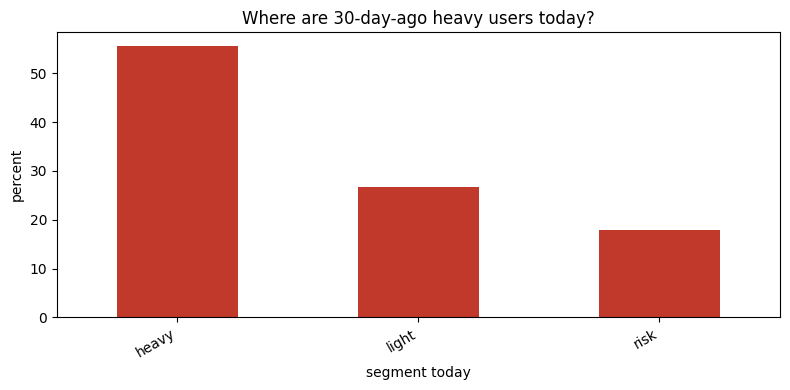

In [14]:
# 30일 전 heavy 유저가 오늘은 어디에 있는가
nday_query = """
SELECT
  past.user_seg AS seg_30days_ago,
  curr.user_seg AS seg_today,
  count(*) AS users,
  round(count(*) / sum(count(*)) OVER () * 100, 1) AS pct
FROM mart_user_segment AS past
LEFT JOIN mart_user_segment AS curr
  ON past.user_id = curr.user_id
 AND curr.target_date = DATE '2026-05-20'
WHERE past.target_date = DATE '2026-05-20' - INTERVAL 30 DAY
  AND past.user_seg = '{seg}'
GROUP BY past.user_seg, curr.user_seg
ORDER BY users DESC;
"""
nday = con.execute(nday_query.format(seg="heavy")).df()
display(nday)

ax = nday.set_index("seg_today")["pct"].plot.bar(figsize=(8, 4), color="#c0392b")
ax.set_title("Where are 30-day-ago heavy users today?")
ax.set_xlabel("segment today"); ax.set_ylabel("percent")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()


30일 전 heavy 유저의 절반 가까이가 다른 세그먼트로 흩어졌습니다. 이걸 **같은 HURR 기준**으로
1일 변화와 나란히 놓고 비교해 보겠습니다 — 둘 다 *heavy 유지율*입니다.

In [15]:
# 같은 'heavy 유지율(HURR)' 을 1일 / 30일 두 시간 축으로 비교
con.execute("""
WITH one_day AS (    -- 어제 heavy → 오늘 heavy
  SELECT round(count_if(user_seg_from = 'heavy' AND user_seg = 'heavy')
    / nullif(count_if(user_seg_from = 'heavy'), 0) * 100, 1) AS hurr_pct
  FROM mart_user_segment
  WHERE target_date = DATE '2026-05-20'
),
thirty_day AS (      -- 30일 전 heavy → 오늘 heavy
  SELECT round(count_if(curr.user_seg = 'heavy')
    / nullif(count(*), 0) * 100, 1) AS hurr_pct
  FROM mart_user_segment AS past
  LEFT JOIN mart_user_segment AS curr
    ON past.user_id = curr.user_id AND curr.target_date = DATE '2026-05-20'
  WHERE past.target_date = DATE '2026-05-20' - INTERVAL 30 DAY
    AND past.user_seg = 'heavy'
)
SELECT '1일 (어제 → 오늘)'     AS horizon, hurr_pct FROM one_day
UNION ALL
SELECT '30일 (30일 전 → 오늘)', hurr_pct FROM thirty_day
""").df()

,horizon,hurr_pct
0,1일 (어제 → 오늘),92.1
1,30일 (30일 전 → 오늘),55.6


같은 쿼리의 출발 세그먼트만 `new` 로 바꾸면, **30일 전에 가입 첫 주를 보내고 있던 유저가
오늘 어디에 있는가**가 나옵니다. 1일 단위의 New Activation 이 ‘8일째에 어디로 갔나’를 본다면,
이 표는 한 달 뒤까지 살아남았는지를 보여 줍니다.


In [16]:
# 30일 전 new 유저가 오늘은 어디에 있는가 — 신규 유저의 N일 안착
nday_new = con.execute(nday_query.format(seg="new")).df()
nday_new


,seg_30days_ago,seg_today,users,pct
0,new,light,6,60.0
1,new,dormant,2,20.0
2,new,heavy,1,10.0
3,new,risk,1,10.0


1일 기준으로는 heavy 유저의 **92.1%**가 다음 날에도 heavy로 남지만, 같은 heavy 그룹을 **30일**
기준으로 보면 그 비율이 **55.6%**까지 떨어집니다. 매일의 작은 이탈이 한 달 동안 누적되면서
30일 전 heavy 유저의 절반 가까이가 light·risk로 흩어진 셈입니다. 1일 HURR이 90%를
넘는다고 안심할 게 아니라, 더 긴 시간 축의 유지율을 함께 봐야 헤비 유저층의 진짜 견고함을
가늠할 수 있습니다.

신규 유저 쪽도 마찬가지입니다. 30일 전 가입 첫 주를 보내던 new 유저 10명 가운데 한 달 뒤에도
heavy·light 로 남은 사람은 7명이고, 나머지 3명은 risk·dormant 로 빠졌습니다. 1일 단위의 New
Activation 이 8일째의 갈림길을 보여 준다면, 이 표는 그 뒤로도 습관이 붙었는지를 보여 줍니다.
`nday_query` 의 `INTERVAL 30 DAY` 를 7이나 14로 바꾸면 다른 시간 축의 변화도 곧바로 볼 수
있습니다. 60일·90일처럼 더 긴 간격을 보려면 적재 셀의 `periods=31` 을 간격+1 이상으로 늘려
마트를 먼저 더 쌓아야 합니다. (참고로, 1일 유지율을 N번 곱해서 장기 유지율을 계산하면 안
됩니다. light로 내려갔다가 다시 heavy로 올라오는 케이스를 놓치기 때문이죠.)

매일 적재된 마트 한 장으로 단기 KPI(실습 3)부터 N일 누적 변화(실습 4)까지 같은 구조 위에서
뽑아낼 수 있다는 것이 이 마트의 힘입니다.